In [1]:
!pip install ultralytics
!pip -q install ultralytics opencv-python scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


YOLO_MODEL_PATH       = "/content/drive/MyDrive/ACK2025_Wafer/FINAL/Wafer_Yolo.pt"
CLASSIFIER_MODEL_PATH = "/content/drive/MyDrive/ACK2025_Wafer/FINAL/Classifier_Model/best_classifier_model_weight.keras"
ENCODER_PATH          = "/content/drive/MyDrive/ACK2025_Wafer/FINAL/Classifier_Model/label_encoder_weight.pkl"
TEST_DATA_ROOT = "/content/drive/MyDrive/ACK2025_Wafer/FINAL/Wafer_Classifiy_Folder"

Mounted at /content/drive


In [3]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import math
from ultralytics import YOLO
import matplotlib.pyplot as plt
from keras.saving import register_keras_serializable
from keras.layers import Layer
from keras.models import load_model

@register_keras_serializable(package="wafer")
class Slice1D(Layer):
    """x[:, start:start+size] 추출"""
    def __init__(self, start, size, **kwargs):
        super().__init__(**kwargs)
        self.start = int(start)
        self.size = int(size)
        self.supports_masking = True
    def call(self, inputs):
        return inputs[:, self.start:self.start + self.size]
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.size)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"start": self.start, "size": self.size})
        return cfg

@register_keras_serializable(package="wafer")
class SafeLog1p(Layer):
    """log1p(max(x, eps))"""
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = float(eps)
        self.supports_masking = True
    def call(self, x):
        x = tf.cast(x, tf.float32)
        return tf.math.log1p(tf.maximum(x, self.eps))
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"eps": self.eps})
        return cfg

@register_keras_serializable(package="wafer")
class RadialPos(Layer):
    """int bin -> float pos = bin/8.0"""
    def __init__(self, denom=8.0, **kwargs):
        super().__init__(**kwargs)
        self.denom = float(denom)
        self.supports_masking = True
    def call(self, x):
        return tf.cast(x, tf.float32) / self.denom
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"denom": self.denom})
        return cfg

@register_keras_serializable(package="wafer")
class SectorAngle(Layer):
    """int bin -> angle rad = bin * (2π / sectors)"""
    def __init__(self, sectors=16, **kwargs):
        super().__init__(**kwargs)
        self.sectors = int(sectors)
        self.supports_masking = True
    def call(self, x):
        return tf.cast(x, tf.float32) * (2.0 * math.pi / float(self.sectors))
    def compute_output_shape(self, input_shape):
        return input_shape
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"sectors": self.sectors})
        return cfg

@register_keras_serializable(package="wafer")
class Sin(Layer):
    def call(self, x):
        return tf.sin(x)
    def compute_output_shape(self, input_shape):
        return input_shape

@register_keras_serializable(package="wafer")
class Cos(Layer):
    def call(self, x):
        return tf.cos(x)
    def compute_output_shape(self, input_shape):
        return input_shape



def visualize_box(img, x1, y1, x2, y2, label, color=(0,255,0)):
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(img, (x1, y1 - th - 10), (x1 + tw, y1), color, -1)
    cv2.putText(img, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [28]:
# 좌표 연속형 특징 반환 함수
def build_cont_features(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm, eps=1e-6):

    # 웨이퍼 중심 기준 결함의 상대 좌표
    dx = xc - wafer_cx
    dy = yc - wafer_cy

    # 반경 정규화(0~1)
    dist_norm = np.sqrt(dx*dx + dy*dy)    # 좌표 간 거리
    r_norm = np.clip(dist_norm / max(wafer_r_norm, eps), 0.0, 1.0)    # 정규화

    # 각도(라디안) 및 sin/cos
    theta = np.arctan2(dy, dx)    # 웨이퍼 중심 기준 결함의 방향
    sin_th = np.sin(theta)        # sin 변환
    cos_th = np.cos(theta)        # cos 변환

    # 파생특징
    area_norm   = bw * bh                           # 결함의 상대적 크기
    aspect_log  = np.log((bw + eps) / (bh + eps))   # 결함의 종횡비
    edge_margin = 1.0 - r_norm                      # 결함과 가장자리간 거리

    # 중심좌표를 [-1,1] 범위로 스케일(반지름 기준)
    x_centered = np.clip((dx / max(wafer_r_norm, eps)), -1.5, 1.5)
    y_centered = np.clip((dy / max(wafer_r_norm, eps)), -1.5, 1.5)

    # 연속형 특징 저장 (중심 좌표의 x y 좌표, 바운딩 박스의 높이밑변, 반지름, sin cos 각도, 상대적 크기, 종횡비, 가장자리간 거리)
    cont = np.array([
        x_centered, y_centered, bw, bh,
        r_norm, sin_th, cos_th, area_norm,
        aspect_log, edge_margin
    ], dtype=np.float32)

    # 출력
    return cont, r_norm, theta

# 결함 분류 함수
def classify_defect(cropped_img, box_coords, image_dims, model, class_names, wafer_cx=0.5, wafer_cy=0.5, wafer_r_norm=0.5,
                    use_four_inputs=False):
    W, H = image_dims
    x1, y1, x2, y2 = box_coords

    # crop 검증
    if x2 <= x1 or y2 <= y1 or cropped_img.size == 0:
        return "INVALID_BOX", 0.0

    # 이미지 입력 준비
    resized = cv2.resize(cropped_img, (128, 128))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype("float32") / 255.0
    img_in = np.expand_dims(rgb, 0)

    # 좌표 특징 준비
    xc, yc, bw, bh = ((x1 + x2)/2)/W, ((y1 + y2)/2)/H, (x2 - x1)/W, (y2 - y1)/H
    cont, r_norm, theta = build_cont_features(xc, yc, bw, bh, wafer_cx, wafer_cy, wafer_r_norm)
    rad_bin = int(np.clip(np.floor(r_norm * 8), 0, 7))
    sec_bin = int(np.floor(((theta % (2*np.pi)) / (2*np.pi)) * 16))

    cont_in = np.array([cont], dtype=np.float32)
    rad_in  = np.array([[rad_bin]])
    sec_in  = np.array([[sec_bin]])

    # 분류 모델 실행
    try:
        # 4개의 입력을 리스트로 전달
        outs = model.predict([img_in, cont_in, rad_in, sec_in], verbose=0)
        probs = outs[0]
    except Exception as e:
        print("classifier forward failed:", repr(e))
        return "CLS_ERROR", 0.0

    # 결과 해석
    top = int(np.argmax(probs))
    conf = float(np.max(probs))
    name = class_names[top] if top < len(class_names) else f"IDX_{top}"
    print(f"결함 종류 => {name} ({conf:.3f})")

    return name, conf


# 탐지 및 분류 함수
def detect_and_show(image_path, yolo_model, classifier_model, encoder, wafer_cx=0.5, wafer_cy=0.5, wafer_r_norm=0.5,
                              use_four_inputs=False):

    # 클래스별 바운딩 박스 색상 정의
    CLASS_COLORS = {
        'Center': (0, 0, 255),        # 빨강
        'Donut': (255, 0, 0),         # 파랑
        'Edge-Loc': (0, 255, 255),    # 노랑
        'Edge-Ring': (255, 0, 255),   # 분홍
        'Loc': (128, 0, 128),         # 보라
        'Near-full': (255, 255, 0),   # 청록
        'Random': (0, 255, 0),        # 초록
        'Scratch': (0, 128, 255),     # 주황
    }

    img = cv2.imread(image_path)
    if img is None:
        print(f"load fail: {image_path}")
        return None

    H, W = img.shape[:2]
    out_img = img.copy()
    class_names = encoder.classes_

    # 결함 탐지
    yolo_results = yolo_model.predict(img, imgsz=640, conf=0.5, verbose=False)
    boxes = yolo_results[0].boxes
    print(f"\n{len(boxes)}개의 결함을 탐지했습니다.")

    for i, b in enumerate(boxes):
        try:
            x1, y1, x2, y2 = map(int, b.xyxy[0].cpu().numpy())

            # 화면 내부로 좌표 클리핑
            x1 = max(0, min(W - 1, x1)); x2 = max(0, min(W - 1, x2))
            y1 = max(0, min(H - 1, y1)); y2 = max(0, min(H - 1, y2))

            if x2 <= x1 or y2 <= y1:
                continue

            # 바운딩 박스 좌표 출력
            print(f"▶︎ box{i}: ({x1},{y1},{x2},{y2})")

            # 분류를 위해 이미지 크롭
            crop = img[y1:y2, x1:x2]

            # classify_defect 함수 호출하여 분류 수행
            pred_class_name, confidence = classify_defect(
                crop,
                (x1, y1, x2, y2),
                (W, H),
                classifier_model,
                class_names,
                wafer_cx=wafer_cx, wafer_cy=wafer_cy, wafer_r_norm=wafer_r_norm,
            use_four_inputs=use_four_inputs
        )

            # --- 시각화 로직 ---
            box_color = CLASS_COLORS.get(pred_class_name, (200, 200, 200)) # 기본값 회색

            cv2.rectangle(out_img, (x1, y1), (x2, y2), box_color, 2)

            label = f"{pred_class_name} {confidence:.2f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)

            # 텍스트 위치 계산 (이미지 경계를 벗어나지 않도록 추가 설정)
            text_y = y1 - 10 if y1 - 10 > th else y1 + th + 10

            # 텍스트 가독성을 위한 글씨 테두리 및 글씨 설정
            cv2.putText(out_img, label, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,255), 3, cv2.LINE_AA)
            cv2.putText(out_img, label, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,255), 2, cv2.LINE_AA)

        except Exception as e:
            print(f"box{i} 처리 중 오류 발생:", repr(e))

    return out_img

모델 및 필요 객체를 로딩합니다...
-> 로딩 완료.
결과 이미지는 'inference_results' 폴더에 저장됩니다.

--- Center 클래스 처리 중 (이미지: Center27.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (261,272,384,392)
결함 종류 => Center (0.448)

--- Donut 클래스 처리 중 (이미지: Donut296.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (154,155,504,520)
결함 종류 => Donut (0.726)

--- Edge-Loc 클래스 처리 중 (이미지: Edge-Loc4677.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (392,528,534,639)
결함 종류 => Edge-Loc (0.521)

--- Edge-Ring 클래스 처리 중 (이미지: Edge-Ring3704.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (0,12,639,639)
결함 종류 => Edge-Ring (0.309)

--- Loc 클래스 처리 중 (이미지: Loc88.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (303,238,479,432)
결함 종류 => Loc (0.335)

--- Near-full 클래스 처리 중 (이미지: Near-full135.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (0,1,639,639)
결함 종류 => Near-full (0.364)

--- Random 클래스 처리 중 (이미지: Random626.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (0,0,638,639)
결함 종류 => Random (0.396)

--- Scratch 클래스 처리 중 (이미지: Scratch369.png) ---

1개의 결함을 탐지했습니다.
▶︎ box0: (33,232,370,455)
결함 종류 => Scratch (0.766)

 모든 클래스 결과 그리드

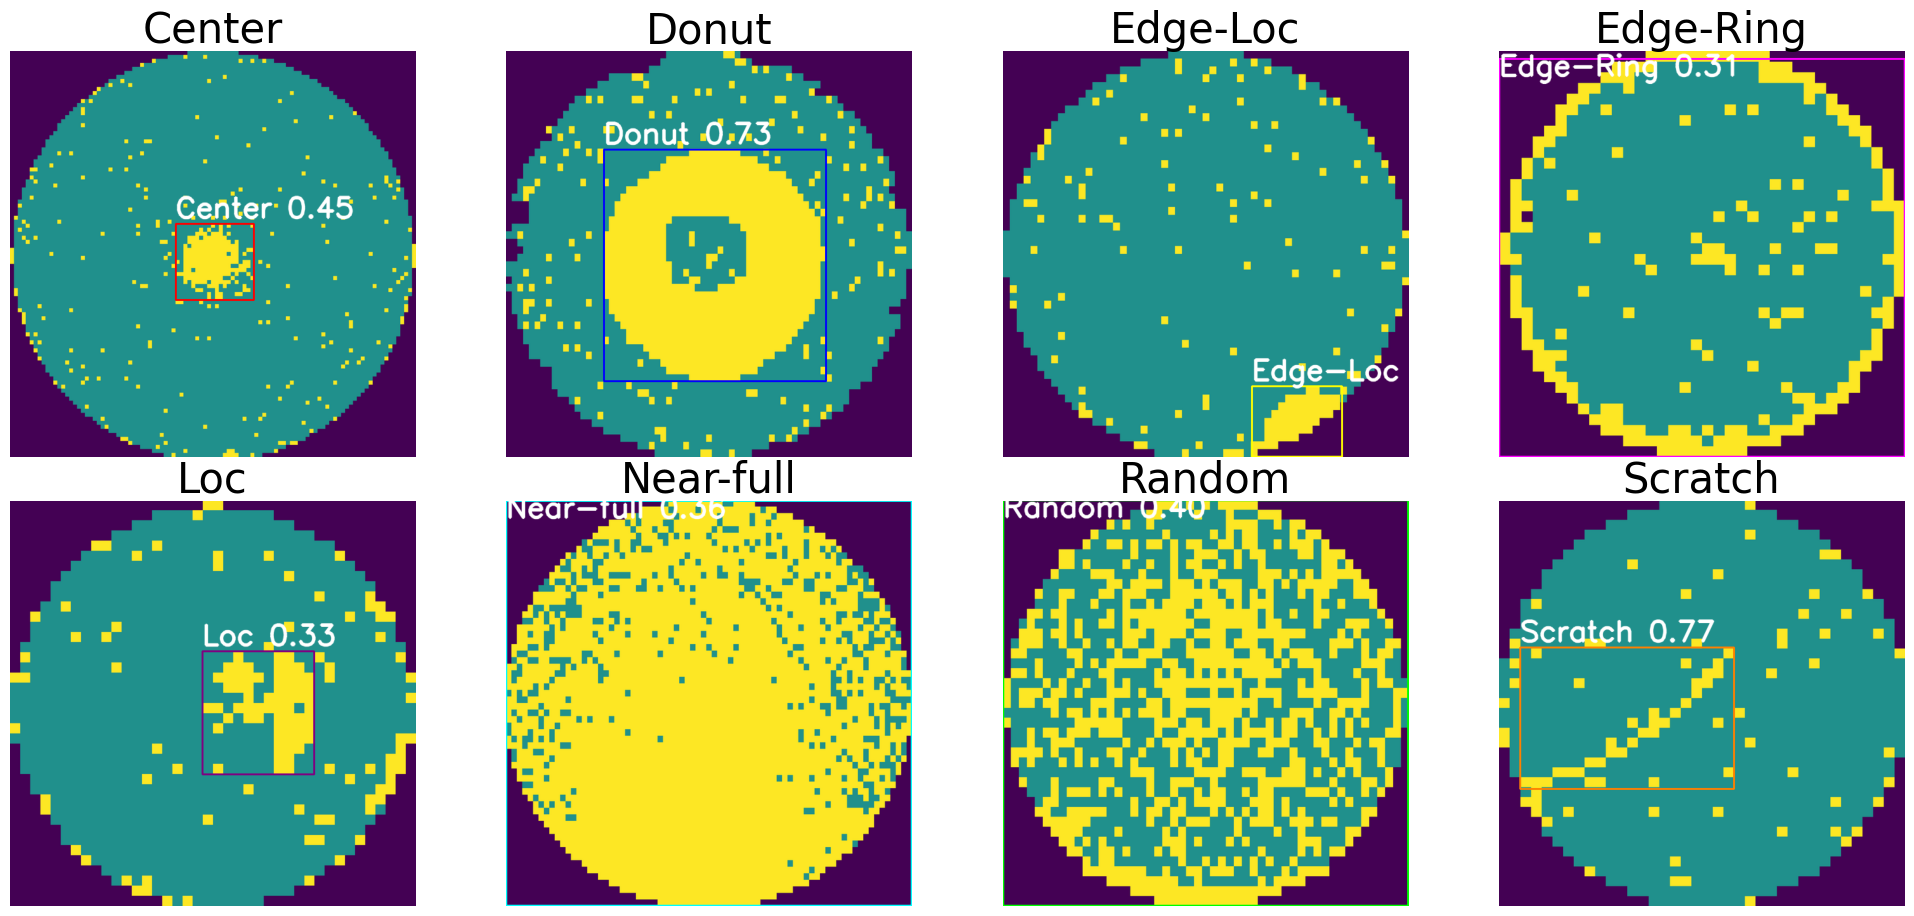

In [29]:
if __name__ == '__main__':

    # 모델 및 필요 객체 로드
    print("모델 및 필요 객체를 로딩합니다...")
    yolo_model = YOLO(YOLO_MODEL_PATH)
    classifier_model = load_model(CLASSIFIER_MODEL_PATH, safe_mode=False)
    encoder = joblib.load(ENCODER_PATH)
    print("-> 로딩 완료.")

    # 결과 이미지를 저장할 폴더 생성
    RESULT_SAVE_DIR = "inference_results"
    os.makedirs(RESULT_SAVE_DIR, exist_ok=True)
    print(f"결과 이미지는 '{RESULT_SAVE_DIR}' 폴더에 저장됩니다.")

    # 결함 이미지를 종합할 그리드 설정 (2행 4열)
    num_rows = 2
    num_cols = 4
    plt.figure(figsize=(num_cols * 5, num_rows * 5)) # 전체 그리드 크기 조절

    # encoder에 저장된 클래스 이름 순서대로 그리드 채우기
    sorted_class_names = sorted(encoder.classes_) # 알파벳 순 정렬

    # 2행 4열에 맞추기 위한 클래스 선택 (총 8개 클래스가 있다고 가정)
    display_classes = sorted_class_names[:num_rows * num_cols]

    # 최종 그리드 이미지 저장 경로
    SAVE_GRID_IMAGE_PATH = "all_class_results_grid.png"

    # 이미지 폴더를 순환하며 탐지 및 분류
    for i, class_name in enumerate(display_classes):
        class_dir = os.path.join(TEST_DATA_ROOT, class_name)
        result_image_for_grid = None # 각 칸에 들어갈 이미지 초기화

        if os.path.isdir(class_dir) and len(os.listdir(class_dir)) > 0:
            # 폴더의 첫 번째 이미지 파일을 선택
            first_image_name = sorted(os.listdir(class_dir))[0] # 첫 번째 이미지
            test_image_path = os.path.join(class_dir, first_image_name)

            print(f"\n--- {class_name} 클래스 처리 중 (이미지: {first_image_name}) ---")
            result_image_for_grid = detect_and_show(test_image_path, yolo_model, classifier_model, encoder)
        else:
            print(f"경고: '{class_name}' 클래스 폴더를 찾을 수 없거나 비어있습니다. 빈칸으로 표시됩니다.")
            # 이미지를 찾을 수 없을 경우 빈 이미지 또는 플레이스홀더를 생성
            result_image_for_grid = np.zeros((200, 200, 3), dtype=np.uint8) # 검은색 빈 이미지
            cv2.putText(result_image_for_grid, "No Image", (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)


        # 그리드에 이미지 추가
        ax = plt.subplot(num_rows, num_cols, i + 1)
        if result_image_for_grid is not None:
            ax.imshow(cv2.cvtColor(result_image_for_grid, cv2.COLOR_BGR2RGB))
            ax.set_title(class_name, fontsize=30) # 각 칸의 제목은 클래스 이름으로
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 전체 제목과 서브플롯 간격 조절

    # 최종 그리드 이미지 저장
    plt.savefig(SAVE_GRID_IMAGE_PATH, bbox_inches='tight', dpi=300)
    print(f"\n 모든 클래스 결과 그리드 이미지 저장 완료: {SAVE_GRID_IMAGE_PATH}")

    plt.show() # 화면에도 표시

